<a href="https://colab.research.google.com/github/Prajuyo030/Fedx-EDA-/blob/main/EDA_!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -FedEx Logistics Performance Analysis



# **Problem Statement**


FedEx Logistics manages a vast global supply chain, handling shipments across multiple regions, countries, and industries. Efficient logistics operations are crucial to ensure timely deliveries, minimize freight costs, and improve customer satisfaction. However, challenges such as shipment delays, high transportation costs, and inconsistencies in vendor agreements (INCO terms) can impact overall supply chain efficiency. This project aims to analyze FedEx's logistics dataset to:

Identify bottlenecks causing shipment delays.
Optimize freight costs by evaluating shipment methods and vendor agreements.
Detect patterns in delivery schedules to predict future delays.

#### **Define Your Business Objective?**

**FedEx Logistics Performance Analysis**



# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [29]:
# Import Libraries
import numpy as np
import pandas as pd
from numpy import loadtxt
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [30]:
# Load Dataset
csv_url = "https://drive.google.com/uc?id=1G3sg45qaljQ9w-bB5i4-n7QAM59cR4xN"
dataset = pd.read_csv(csv_url)


### Dataset First View

In [31]:
# Dataset First Look
dataset.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


### Dataset Rows & Columns count

In [32]:
# Dataset Rows & Columns count
dataset.shape

(10324, 33)

### Dataset Information

In [33]:
# Dataset Info
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [34]:
# Dataset Duplicate Value Count
len(dataset[dataset.duplicated()])

0

#### Missing Values/Null Values

In [35]:
# Missing Values/Null Values Count
print(dataset.isnull().sum())

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

<Axes: >

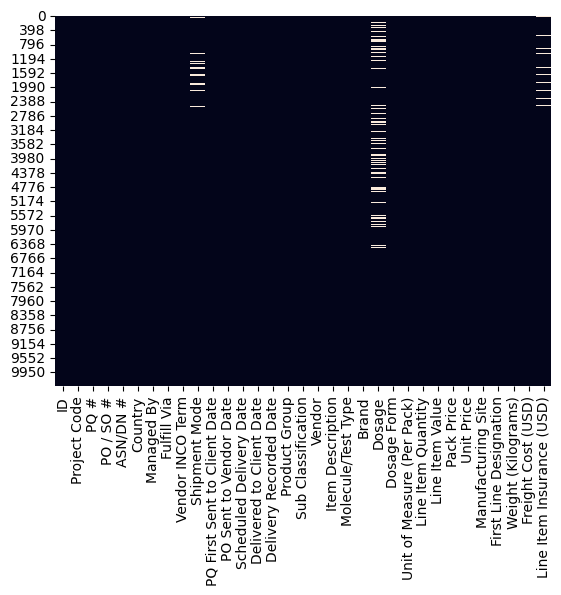

In [36]:
# Visualizing the missing values
sns.heatmap(dataset.isnull(), cbar=False)

### What did you know about your dataset?

The FedX dataset contains 10,324 shipment records with 33 columns related to logistics operations, vendor details, product information, costs, and delivery timelines

## ***2. Understanding Your Variables***

In [37]:
# Dataset Columns
dataset.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [38]:
# Dataset Describe
dataset.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


### Variables Description

**ID:** Unique identifier for each logistics record, used for tracking and referencing specific shipments.

**Project Code:-** Code representing the project or initiative related to the shipment

**PQ #:-** Price Quotation reference number tied to the shipment.

**PO / SO #:-** Purchase Order or Sales Order number associated with the shipment.

**ASN/DN #:-** Advanced Shipment Notice or Delivery Note reference number associated with the shipment.

**Country:-** Destination country to which the shipment is sent.

**Managed By:-** Team or unit managing the shipment project

**Fulfill Via:-** Method of fulfillment used

**Vendor INCO Term:-** Incoterms defining shipment agreements indicating responsibilities and costs.

**Shipment Mode:-** Transportation mode used, such as air, sea, or road.

**PQ First Sent to Client Date:-** Date when the price quotation was first sent to the client.

**PO Sent to Vendor Date:-** Date when the purchase order was sent to the vendor.

**Scheduled Delivery Date:-** The planned delivery date for the shipment.

**Delivered to Client Date:-** Actual date when the shipment was delivered to the client.

**Delivery Recorded Date:-** Date when the delivery event was officially recorded.

**Product Group:-** Broad classification of the product being shipped
Sub Classification: Further categorization within the product group.

**Vendor:-** Company supplying the goods.

**Item Description:-** Detailed description of the shipped item.

**Molecule/Test Type:-** Type of pharmaceutical molecule or test
Brand: Brand name of the product.

**Dosage:-** Dosage strength of the pharmaceutical product.

**Dosage Form:-** Physical form of the product

**Unit of Measure (Per Pack):-** Number of units contained in each pack.

**Line Item Quantity:-** Total quantity of units shipped for the line item.

**Line Item Value:-** Total monetary value of the line item shipped.

**Pack Price:-** Price per pack of the item.

**Unit Price:-** Price per individual unit.

**Manufacturing Site:-** Location where the item was manufactured.

**First Line Designation:-** Indicator whether the product is designated for first-line use (typically frontline treatment).

**Weight (Kilograms):-** Weight of the shipment item.

**Freight Cost (USD):-** Cost of shipping the item.

**Line Item Insurance (USD):-** Insurance cost associated with the line item shipment.



### Check Unique Values for each variable.

In [44]:

dataset.nunique()

,0
ID,10324
Project Code,142
PQ #,1237
PO / SO #,6233
ASN/DN #,7030
Country,43
Managed By,4
Fulfill Via,2
Vendor INCO Term,8
Shipment Mode,4


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Creating a copy of the current dataset and assigning to df
df=dataset.copy()
df.describe(include='all')

In [ ]:
#converting columns
# list of all date columns
date_cols = ["PQ First Sent to Client Date","PO Sent to Vendor Date","Scheduled Delivery Date","Delivered to Client Date","Delivery Recorded Date"]

# convert to datetime
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
# check result
print(df[date_cols].info())




In [ ]:
# Convert Numeric Columns Stored as Object
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')


In [ ]:
#cleaning the data
df = df.dropna(subset=['Shipment Mode'])
df = df.dropna(subset=['Dosage'])
df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(0)

#checking
print(df.isnull().sum())

#ploting the heatmap
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values in df")
plt.show()

In [ ]:
# Check missing values in the PQ First Sent to Client Date and PO Sent to Vendor Date columns
missing_pq = df['PQ First Sent to Client Date'].isnull().sum()
missing_po = df['PO Sent to Vendor Date'].isnull().sum()

print(f"Missing PQ First Sent to Client Date: {missing_pq}")
print(f"Missing PO Sent to Vendor Date: {missing_po}")

# Rows with missing PQ First Sent to Client Date
missing_pq_rows = df[df['PQ First Sent to Client Date'].isnull()]

In [ ]:
# Rows with missing PQ First Sent to Client Date
missing_pq_rows = df[df['PQ First Sent to Client Date'].isnull()]

# Rows with missing PO Sent to Vendor Date
missing_po_rows = df[df['PO Sent to Vendor Date'].isnull()]

# Rows missing both
missing_both_rows = df[df['PQ First Sent to Client Date'].isnull() & df['PO Sent to Vendor Date'].isnull()]

print(f"Rows missing PQ Date: {len(missing_pq_rows)}")
print(f"Rows missing PO Date: {len(missing_po_rows)}")
print(f"Rows missing both: {len(missing_both_rows)}")

In [ ]:
# Missing PQ Date by Vendor
missing_pq_by_vendor = missing_pq_rows['Vendor'].value_counts()
print("Missing PQ Date by Vendor:\n", missing_pq_by_vendor)


In [ ]:
# Missing PO Date by Country
missing_po_by_country = missing_po_rows['Country'].value_counts()
print("Missing PO Date by Country:\n", missing_po_by_country)

In [ ]:
# Missing both by Product Group
missing_both_by_product = missing_both_rows['Product Group'].value_counts()
print("Missing both dates by Product Group:\n", missing_both_by_product)

In [ ]:
#fright cost

#  Copy original to clean column
df['Freight Cost Clean'] = df['Freight Cost (USD)'].astype(str).str.strip()

#: Categorize
df.loc[df['Freight Cost Clean'].str.contains("included", case=False, na=False), 'Freight Cost Clean'] = "Included in Commodity Cost"
df.loc[df['Freight Cost Clean'].str.contains("see", case=False, na=False), 'Freight Cost Clean'] = "Other/Reference"
df.loc[df['Freight Cost Clean'].str.contains("invoiced", case=False, na=False), 'Freight Cost Clean'] = "Invoiced Separately"

# Mark numeric
df.loc[df['Freight Cost Clean'].str.replace('.', '', 1).str.replace('-', '', 1).str.isnumeric(), 'Freight Cost Clean'] = "Numeric"

#  Numeric conversion for actual cost
df['Freight Cost Numeric'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

#  Counts per category (independent of numeric conversion)
category_counts = df['Freight Cost Clean'].value_counts()
print("\nFreight Category Counts:")
print(category_counts)

#  Average for numeric only
avg_freight = df.loc[df['Freight Cost Clean'] == "Numeric", 'Freight Cost Numeric'].mean()
print("\nAverage Freight Cost (Numeric only):", avg_freight)

# Proper summary
summary = pd.DataFrame({
    "Freight Cost Clean": category_counts.index,
    "Count": category_counts.values
})

# Merge in average cost only for numeric
numeric_avg = df.loc[df['Freight Cost Clean'] == "Numeric", 'Freight Cost Numeric'].mean()
summary['Average_Freight'] = summary['Freight Cost Clean'].apply(
    lambda x: numeric_avg if x == "Numeric" else None
)

summary['Percentage'] = (summary['Count'] / len(df) * 100).round(2)

print("\nSummary Table:")
print(summary)


In [ ]:
# Calculate Average Unit Price
avg_unit_price = df["Unit Price"].mean()
print("Average Unit Price:", avg_unit_price)

In [ ]:
df['delivery_delay_days'] = (
    df['Delivered to Client Date'] - df['Scheduled Delivery Date']
).dt.days

df['is_delayed'] = df['delivery_delay_days'] > 0

df['total_logistics_cost'] = (
    df['Freight Cost (USD)'] + df['Line Item Insurance (USD)']
)

df['delivery_month'] = df['Delivered to Client Date'].dt.to_period('M')

In [ ]:
#  Average Unit Price by Vendor
avg_price_vendor = df.groupby("Vendor")["Unit Price"].mean().sort_values(ascending=False)
print("\nAverage Unit Price by Vendor:\n", avg_price_vendor)

#  Average Unit Price by Country
avg_price_country = df.groupby("Country")["Unit Price"].mean().sort_values(ascending=False)
print("\nAverage Unit Price by Country:\n", avg_price_country)

#  Average Unit Price by Shipment Mode
avg_price_mode = df.groupby("Shipment Mode")["Unit Price"].mean().sort_values(ascending=False)
print("\nAverage Unit Price by Shipment Mode:\n", avg_price_mode)

In [ ]:
# On_Time and Lead_Time columns need to be created before use.

df['On_Time'] = np.where(df['delivery_delay_days'] <= 0, 1, 0) # 1 if delivery was on/before schedule, else 0
df['Lead_Time'] = (df['Delivered to Client Date'] - df['PO Sent to Vendor Date']).dt.days # Lead Time

# On-Time Delivery Rate (Overall)
on_time_rate = df['On_Time'].mean() * 100
print(f" Overall On-Time Delivery Rate: {on_time_rate:.2f}%")

# Average Lead Time (Overall)
avg_lead_time = df['Lead_Time'].mean()
print(f" Overall Average Lead Time: {avg_lead_time:.2f} days")

# Grouped Analysis

#  By Vendor
on_time_vendor = df.groupby('Vendor')['On_Time'].mean().sort_values(ascending=False) * 100
lead_time_vendor = df.groupby('Vendor')['Lead_Time'].mean().sort_values()
print("\n On-Time Delivery Rate by Vendor (%):\n", on_time_vendor.head())
print("\n Average Lead Time by Vendor (days):\n", lead_time_vendor.head())

#  By Country
on_time_country = df.groupby('Country')['On_Time'].mean().sort_values(ascending=False) * 100
lead_time_country = df.groupby('Country')['Lead_Time'].mean().sort_values()
print("\n On-Time Delivery Rate by Country (%):\n", on_time_country.head())
print("\n Average Lead Time by Country (days):\n", lead_time_country.head())

#  By Shipment Mode
on_time_mode = df.groupby('Shipment Mode')['On_Time'].mean().sort_values(ascending=False) * 100
lead_time_mode = df.groupby('Shipment Mode')['Lead_Time'].mean().sort_values()
print("\n On-Time Delivery Rate by Shipment Mode (%):\n", on_time_mode)
print("\n Average Lead Time by Shipment Mode (days):\n", lead_time_mode)


### What all manipulations have you done and insights you found?

Converted raw date columns into datetime for calculations.

**Created new features:**

Delay_Days → Delivered date − Scheduled date.

On_Time → 1 if delivery was on/before schedule, else 0.

Lead_Time → Delivered date − PO Sent to Vendor date.

Aggregated data by Vendor, Country, and Shipment Mode to compare performance.

**Calculated KPIs:**

Overall On-Time Delivery Rate

Overall Average Lead Time

On-Time % by Vendor, Country, Shipment Mode

Lead Time by Vendor, Country, Shipment Mode

** Insights from the Results**

Overall Performance:

On-Time Delivery Rate = 87.09% → fairly good reliability.

Average Lead Time = 109.35 days → shipments take ~3.5 months on average.

**Vendors:**

Some vendors (e.g., ABBOTT LABORATORIES, ABBOTT LOGISTICS B.V.) consistently delivered 100% on-time.

But lead times vary — e.g., ABBOTT PUERTO RICO had ~23 days, while ABBOTT LOGISTICS B.V. had ~34 days.

One vendor showed a negative lead time (-2.5 days), which likely indicates a data entry error.

Countries:

Countries like Afghanistan, Angola, Belize, Burkina Faso, Lebanon had 100% on-time rate.

But average lead times differ — e.g., Cameroon (73 days) and Togo (55 days) are much slower than Benin (46 days).

Suggests that regional logistics/customs impact delivery.

Shipment Mode:

Air (89.4% on-time) is the most reliable, but lead time is still high (~119 days).

Truck (55 days) is much faster, but less reliable (83.7% on-time).

Ocean Freight (177 days) is the slowest and least reliable (82.3% on-time).

Shows a clear trade-off: speed vs cost vs reliability.

**Freight Cost Analysis**

Average freight cost (numeric only) = $10,749 per shipment.

Freight cost categories show:

56% numeric (actual freight cost recorded)

26% “Other/Reference” → ambiguous references, weakens data quality.

16% included in commodity cost → hides true freight expense.

2% invoiced separately → scattered cost tracking.

Freight costs increase with weight, but higher costs do not guarantee faster delivery (inefficiency).





## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

# Calculate missing values
missing_counts = df[date_cols].isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
# Plot Missing Percentages
plt.figure(figsize=(10, 8))
missing_percent.plot(kind="bar", edgecolor="black")
plt.title("Missing Values in Date Columns (Percentage)", fontsize=14)
plt.ylabel("Percentage of Missing Values (%)")
plt.xlabel("Date Columns")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar chart clearly compares missing percentages across process dates.

##### 2. What is/are the insight(s) found from the chart?

PO Sent to Vendor Date has very high missing values compared to other process dates.


##### 3. Will the gained insights help creating a positive business impact?


Improving PO documentation can enhance process transparency and supply chain traceability.





#### Chart - 2

In [ ]:
#Distribution of Delivery Delay
plt.figure()
df['delivery_delay_days'].plot(kind='hist', bins=40)
plt.title("Distribution of Delivery Delay (Days)")
plt.xlabel("Delay (Days)")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is ideal for understanding distribution and identifying extreme delay values.

##### 2. What is/are the insight(s) found from the chart?

Most deliveries are near scheduled dates, but there are significant delay outliers.

##### 3. Will the gained insights help creating a positive business impact?


#### Chart - 3

In [ ]:
#Top 10 Countries by Average Delay
plt.figure()
df.groupby('Country')['delivery_delay_days'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Countries by Average Delay")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart clearly compares cost differences between shipment modes.

##### 2. What is/are the insight(s) found from the chart?

Air Charter has the highest average freight cost among all modes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



Helps optimize shipment mode selection to balance cost and speed.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code
# Monthly Average Delivery Delay Trend
plt.figure()
df.groupby('delivery_month')['delivery_delay_days'].mean().plot()
plt.title("Monthly Average Delivery Delay")
plt.xlabel("Month")
plt.ylabel("Avg Delay (Days)")
plt.show()

##### 1. Why did you pick the specific chart?

Line chart is ideal to observe trends and seasonal patterns over time.


##### 2. What is/are the insight(s) found from the chart?

Certain periods show spikes in delays, indicating possible seasonal congestion.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports proactive planning and capacity adjustments during peak periods.

#### Chart - 5

In [ ]:
# Chart - 5 visualization code
# Average Freight Cost by Shipment Mode
plt.figure()
df.groupby('Shipment Mode')['Freight Cost (USD)'].mean().plot(kind='bar')
plt.title("Average Freight Cost by Shipment Mode")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart clearly compares cost differences between shipment modes.

##### 2. What is/are the insight(s) found from the chart?

Air Charter has the highest average freight cost among all modes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps optimize shipment mode selection to balance cost and speed.

#### Chart - 6

In [ ]:
# Chart - 6 visualization code
#Top 10 Vendors by Average Delay
plt.figure()
df.groupby('Vendor')['delivery_delay_days'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Vendors by Average Delay")
plt.show()

##### 1. Why did you pick the specific chart?


Bar chart highlights performance differences among vendors.

##### 2. What is/are the insight(s) found from the chart?

Some vendors consistently show higher delivery delays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports vendor performance evaluation and contract renegotiation decisions.

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

plt.figure(figsize=(7,7))
plt.pie(
    summary['Percentage'],
    labels=summary['Freight Cost Clean'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Percentage Share of Freight Cost Categories")
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart was chosen because it helps compare the proportion of different freight cost categories and shows which category contributes the most to the dataset.

##### 2. What is/are the insight(s) found from the chart?

Most freight records fall under numeric freight costs, while a considerable portion contains references such as "Included in Commodity Cost" or "Other/Reference". This indicates inconsistency in freight cost recording.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Standardizing freight cost records can improve transparency, budgeting accuracy, and logistics planning.

Negative impact:
Incomplete freight records may hide actual transportation expenses, leading to poor cost estimation and inefficient decision-making.

#### Chart - 8

In [ ]:
# Chart - 8 visualization code
numeric_data = df.loc[
    df['Freight Cost Clean']=="Numeric",
    'Freight Cost Numeric'
]

plt.figure(figsize=(8,5))
plt.hist(numeric_data, bins=30)
plt.title("Distribution of Numeric Freight Costs")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,4))
plt.boxplot(numeric_data, vert=False)
plt.title("Freight Cost Outlier Analysis")
plt.xlabel("Freight Cost (USD)")
plt.show()


##### 1. Why did you pick the specific chart?

Histogram helps understand distribution patterns, while a boxplot is useful for identifying outliers in freight costs.

##### 2. What is/are the insight(s) found from the chart?

Most shipments have lower freight costs, but a few shipments show extremely high values, indicating cost outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying expensive shipments helps optimize transportation strategies and negotiate vendor costs.

Negative impact:
Frequent high-cost outliers may indicate inefficiencies or expensive shipment routes.

#### Chart - 9

In [ ]:
# Chart - 9 visualization code
#
top_countries = avg_price_country.head(10)

plt.figure(figsize=(8,5))
plt.bar(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Average Unit Price")
plt.xlabel("Country")
plt.ylabel("Average Unit Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts make it easier to compare average unit prices between countries.

##### 2. What is/are the insight(s) found from the chart?

Some countries have significantly higher average unit prices, suggesting regional pricing differences or supply chain complexity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. High-cost regions can be analyzed further to improve procurement and distribution strategies.

Negative impact:
Persistently high prices in specific countries may reduce profitability.

#### Chart - 10

In [ ]:
# Chart - 10 visualization code
plt.figure(figsize=(6,4))
plt.bar(avg_price_mode.index, avg_price_mode.values)
plt.title("Average Unit Price by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Average Unit Price")
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

Bar charts clearly compare average unit prices across shipment modes.

##### 2. What is/are the insight(s) found from the chart?

Shipment modes differ in associated unit prices, showing a relationship between transportation method and overall logistics cost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Businesses can choose shipment methods based on urgency and cost efficiency.

Negative impact:
Overuse of expensive shipment modes may increase operational costs.

#### Chart - 11

In [ ]:
# Chart - 11 visualization code
# Weight vs Freight Cost (Correlation)
plt.figure()
plt.scatter(df['Weight (Kilograms)'], df['Freight Cost (USD)'])
plt.xlabel("Weight (Kilograms)")
plt.ylabel("Freight Cost (USD)")
plt.title("Weight vs Freight Cost")
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plots are useful for understanding relationships between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Freight cost generally increases with shipment weight, but some shipments have unusually high costs despite lower weight.

Answer Here

#### Chart - 12

In [ ]:
# Missing PO Date by Country

plt.figure(figsize=(20,10))
sns.barplot(x=missing_po_by_country.index, y=missing_po_by_country.values, palette='Blues_r')
plt.title('Missing PO Sent to Vendor Date by Country')
plt.xticks(rotation=45)
plt.ylabel('Number of Missing Records')
plt.show()


##### 1. Why did you pick the specific chart?

Bar chart effectively compares missing records across countries.

##### 2. What is/are the insight(s) found from the chart?

Certain countries have a high number of missing PO dates, indicating poor documentation or incomplete tracking processes.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.



Missing values in PQ First Sent to Client Date and PO Sent to Vendor Date → indicates incomplete order tracking.

Some lead times are negative (e.g., -2.5 days) → clear data entry or recording issues.

Freight cost references like “See DN-4282” → inconsistent data entry, needs standardization.

# **Conclusion**

Write the conclusion here.

1.   Delays are mainly driven by shipment mode (Ocean & Air inefficiencies), specific vendors, and certain regions.
2.   Process optimization with vendors + better freight recording + mode optimization can reduce delays and costs.
3. Strengthen supply chain resilience, ensuring both affordability and accessibility of medicines globally.
4.  Some shipments have low Line Item Value per shipment → inefficient logistics.
Recommendation:
Increase average line item value per shipment by bundling orders.
Track LIV trends per vendor & country to identify inefficiencies.
Create dashboards for real-time monitoring.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [ ]:

df.head()

In [ ]:
# Save cleaned dataset
df.to_csv('cleaned_dataset.csv', index=False)

# Download
from google.colab import files
files.download('cleaned_dataset.csv')